# **1. Configuración**

## Imports


In [1]:
import random, numpy as np, pandas as pd, matplotlib.pyplot as plt
import torch, torch.nn as nn, torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import pennylane as qml
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, balanced_accuracy_score, f1_score, roc_auc_score, average_precision_score, confusion_matrix

## Semillas


In [2]:
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True

## Device


In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu"); print(DEVICE)

cuda


## Dataset


In [4]:
TRAIN_RATIO, VAL_RATIO, TEST_RATIO = 0.70, 0.15, 0.15
BATCH_SIZE = 32

## Modelo


In [5]:
LATENT_DIM = 3

QUBITS_LIST = [1]
N_QNN_LAYERS = 8
CHUNK_PATCHES = 1048576

EPOCHS = 50

CNN_LR = 1e-4
QNN_LR = 5e-2

WEIGHT_DECAY = 1e-5

## Etiquetas


In [6]:
LABEL_NEG, LABEL_POS = -1, 1
CLASS_NAMES = {LABEL_NEG: "Normal", LABEL_POS: "Pneumonia"}

## Resumen

In [7]:
print("=" * 70); print("CNN → z3 → DR-QNN batched\nLoss principal: (<Z> - y)^2"); print("=" * 70); print(f"Device: {DEVICE}\nSplit: {TRAIN_RATIO:.2f}/{VAL_RATIO:.2f}/{TEST_RATIO:.2f}\nBatch size: {BATCH_SIZE}\nLatent dim: {LATENT_DIM}\nQubits: {QUBITS_LIST}\nQNN layers: {N_QNN_LAYERS}\nCHUNK_PATCHES: {CHUNK_PATCHES}\nEpochs: {EPOCHS}\nCNN LR: {CNN_LR}\nQNN LR: {QNN_LR}"); print("=" * 70)

CNN → z3 → DR-QNN batched
Loss principal: (<Z> - y)^2
Device: cuda
Split: 0.70/0.15/0.15
Batch size: 32
Latent dim: 3
Qubits: [1]
QNN layers: 8
CHUNK_PATCHES: 1048576
Epochs: 50
CNN LR: 0.0001
QNN LR: 0.05


# **2. Carga y nuevo split 70/15/15**


## Ruta del dataset


In [8]:
DATA_PATH = r"C:\Users\lapic\datasets\medmnist\pneumoniamnist.npz"

## Carga original


In [9]:
data = np.load(DATA_PATH)
X_train_raw, X_val_raw, X_test_raw = data["train_images"], data["val_images"], data["test_images"]
y_train_raw, y_val_raw, y_test_raw = data["train_labels"].squeeze(), data["val_labels"].squeeze(), data["test_labels"].squeeze()

## Unir train + val + test originales


In [10]:
X_all_raw = np.concatenate([X_train_raw, X_val_raw, X_test_raw], axis=0)
y_all_raw = np.concatenate([y_train_raw, y_val_raw, y_test_raw], axis=0)

## Convertir etiquetas a {-1, +1}


In [11]:
y_all = np.where(y_all_raw == 1, LABEL_POS, LABEL_NEG).astype(np.float32)

## Nuevo split estratificado 70/15/15


In [12]:
X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X_all_raw, y_all, train_size=TRAIN_RATIO, random_state=SEED, stratify=y_all, shuffle=True)
relative_val_ratio = VAL_RATIO / (VAL_RATIO + TEST_RATIO)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, train_size=relative_val_ratio, random_state=SEED, stratify=y_temp, shuffle=True)

## Distribuciones


In [13]:
def print_split_distribution(name, X, y):
    values, counts = np.unique(y, return_counts=True)
    print(f"\n{name}\nX: {X.shape}\ny: {y.shape}")
    for value, count in zip(values, counts):
        percentage = 100 * count / len(y)
        print(f"{CLASS_NAMES[int(value)]} ({int(value)}): {count} ({percentage:.2f}%)")

print("=" * 70); print("Dataset original unido"); print("=" * 70); print(f"X_all_raw: {X_all_raw.shape}\ny_all: {y_all.shape}\nPixel range: {X_all_raw.min()} {X_all_raw.max()}")
print_split_distribution("Nuevo TRAIN", X_train_raw, y_train); print_split_distribution("Nuevo VAL", X_val_raw, y_val); print_split_distribution("Nuevo TEST", X_test_raw, y_test)

Dataset original unido
X_all_raw: (5856, 28, 28)
y_all: (5856,)
Pixel range: 0 255

Nuevo TRAIN
X: (4099, 28, 28)
y: (4099,)
Normal (-1): 1108 (27.03%)
Pneumonia (1): 2991 (72.97%)

Nuevo VAL
X: (878, 28, 28)
y: (878,)
Normal (-1): 237 (26.99%)
Pneumonia (1): 641 (73.01%)

Nuevo TEST
X: (879, 28, 28)
y: (879,)
Normal (-1): 238 (27.08%)
Pneumonia (1): 641 (72.92%)


## Resumen en tabla


In [14]:
split_df = pd.DataFrame({"Split": ["Train", "Validation", "Test"], "Samples": [len(y_train), len(y_val), len(y_test)], "Normal (-1)": [np.sum(y_train == LABEL_NEG), np.sum(y_val == LABEL_NEG), np.sum(y_test == LABEL_NEG)], "Pneumonia (+1)": [np.sum(y_train == LABEL_POS), np.sum(y_val == LABEL_POS), np.sum(y_test == LABEL_POS)]})
display(split_df)

,Split,Samples,Normal (-1),Pneumonia (+1)
0,Train,4099,1108,2991
1,Validation,878,237,641
2,Test,879,238,641


## Visualización rápida del nuevo train


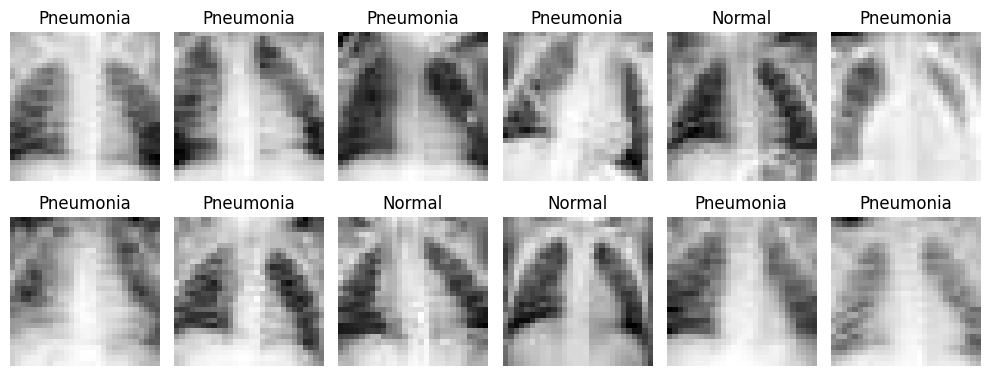

In [15]:
N_SHOW = 12
plt.figure(figsize=(10, 4))
for i in range(N_SHOW):
    plt.subplot(2, 6, i + 1); plt.imshow(X_train_raw[i], cmap="gray"); plt.title(CLASS_NAMES[int(y_train[i])]); plt.axis("off")
plt.tight_layout(); plt.show()

# **3. Preprocesamiento**


## Conversión a float32


In [16]:
X_train = X_train_raw.astype(np.float32)
X_val   = X_val_raw.astype(np.float32)
X_test  = X_test_raw.astype(np.float32)

## Escalamiento [0,1]


In [17]:
X_train /= 255.0; X_val /= 255.0; X_test /= 255.0

## Estadísticas SOLO del train


In [18]:
train_mean = X_train.mean(); train_std = X_train.std(); print(f"Train mean: {train_mean}\nTrain std : {train_std}")

Train mean: 0.5721642971038818
Train std : 0.16829563677310944


## Normalización: $x_{norm} = (x - μ_{train}) / σ_{train}$

In [19]:
X_train = (X_train - train_mean) / train_std
X_val   = (X_val   - train_mean) / train_std
X_test  = (X_test  - train_mean) / train_std

## Canal CNN


In [20]:
X_train = np.expand_dims(X_train, axis=1)
X_val = np.expand_dims(X_val, axis=1)
X_test = np.expand_dims(X_test, axis=1)

## Tensores


In [21]:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
X_val_t = torch.tensor(X_val, dtype=torch.float32)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.float32)
y_val_t = torch.tensor(y_val, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.float32)

## Resumen


In [22]:
print("=" * 70); print(f"X_train_t: {X_train_t.shape}\nX_val_t: {X_val_t.shape}\nX_test_t: {X_test_t.shape}\n\ny_train_t: {y_train_t.shape}\ny_val_t: {y_val_t.shape}\ny_test_t: {y_test_t.shape}\n\nTrain mean: {train_mean}\nTrain std: {train_std}"); print("=" * 70)

X_train_t: torch.Size([4099, 1, 28, 28])
X_val_t: torch.Size([878, 1, 28, 28])
X_test_t: torch.Size([879, 1, 28, 28])

y_train_t: torch.Size([4099])
y_val_t: torch.Size([878])
y_test_t: torch.Size([879])

Train mean: 0.5721642971038818
Train std: 0.16829563677310944


# **4. DataLoaders**


## Dataset


In [23]:
class TensorImageDataset(Dataset):
    def __init__(self, X, y):
        self.X, self.y = X, y
    def __len__(self):
        return len(self.y)
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TensorImageDataset(X_train_t, y_train_t)
val_dataset = TensorImageDataset(X_val_t, y_val_t)
test_dataset = TensorImageDataset(X_test_t, y_test_t)

## DataLoaders


In [24]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

## Sanity batch


In [25]:
xb, yb = next(iter(train_loader))
print("=" * 70); print("DataLoaders"); print("=" * 70)
print(f"Train batches: {len(train_loader)}\nVal batches: {len(val_loader)}\nTest batches: {len(test_loader)}\n\nxb: {xb.shape} {xb.dtype}\nyb: {yb.shape} {yb.dtype}\n\ny min/max: {yb.min().item()} {yb.max().item()}\nx min/max: {xb.min().item()} {xb.max().item()}")
print("=" * 70)

DataLoaders
Train batches: 129
Val batches: 28
Test batches: 28

xb: torch.Size([32, 1, 28, 28]) torch.float32
yb: torch.Size([32]) torch.float32

y min/max: -1.0 1.0
x min/max: -3.399757146835327 2.1693408489227295


# **5. CNN extractor z3**


## Arquitectura


In [26]:
class CNNFeatureExtractor(nn.Module):
    def __init__(self, latent_dim=LATENT_DIM):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2),
            nn.Conv2d(8, 16, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2)
        )
        self.pool = nn.AdaptiveAvgPool2d((1, 1))
        self.to_z = nn.Linear(16, latent_dim)

    def forward(self, x):
        h = self.features(x)
        h = self.pool(h)
        h = torch.flatten(h, 1)
        return self.to_z(h)

## Sanity forward


In [27]:
cnn_test = CNNFeatureExtractor().to(DEVICE)
xb, yb = next(iter(train_loader)); xb = xb.to(DEVICE)
with torch.no_grad(): z_test = cnn_test(xb)
print("=" * 70); print("CNN extractor z3"); print("=" * 70); print(f"Input: {xb.shape}\nz: {z_test.shape}\nz min: {z_test.min().item()}\nz max: {z_test.max().item()}"); print("=" * 70)

CNN extractor z3
Input: torch.Size([32, 1, 28, 28])
z: torch.Size([32, 3])
z min: -0.10587507486343384
z max: 0.3972811698913574


# **6. DR-QNN batched**


## Circuito cuántico

In [28]:
def make_dr_qnn_qnode(n_qubits):
    dev = qml.device("default.qubit", wires=n_qubits)
    @qml.qnode(dev, interface="torch", diff_method="backprop")
    def qnode(z, theta, phi):
        for layer in range(N_QNN_LAYERS):
            for q in range(n_qubits):
                qml.RZ(z[:, 0], wires=q); qml.RY(z[:, 1], wires=q); qml.RZ(z[:, 2], wires=q)
            for q in range(n_qubits):
                qml.RZ(theta[layer, q, 0], wires=q); qml.RY(theta[layer, q, 1], wires=q); qml.RZ(theta[layer, q, 2], wires=q)
            if n_qubits > 1:
                for q in range(n_qubits - 1):
                    qml.CRot(phi[layer, q, 0], phi[layer, q, 1], phi[layer, q, 2], wires=[q + 1, q])
        return qml.expval(qml.PauliZ(0))
    return qnode

## Módulo DR-QNN


In [29]:
class DRQNN(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        self.qnode = make_dr_qnn_qnode(n_qubits)
        self.theta = nn.Parameter(0.01 * torch.randn(N_QNN_LAYERS, n_qubits, 3, dtype=torch.float32))
        if n_qubits > 1:
            self.phi = nn.Parameter(torch.zeros(N_QNN_LAYERS, n_qubits - 1, 3, dtype=torch.float32))
        else:
            self.phi = nn.Parameter(torch.zeros(N_QNN_LAYERS, 0, 3, dtype=torch.float32), requires_grad=False)

    def forward(self, z):
        outputs = []
        for z_chunk in torch.split(z, CHUNK_PATCHES, dim=0):
            outputs.append(self.qnode(z_chunk, self.theta, self.phi))
        return torch.cat(outputs, dim=0).float()

## Sanity check


In [30]:
qnn_test = DRQNN(n_qubits=1).to(DEVICE)
z_test = z_test.to(DEVICE)
with torch.no_grad(): exp_z_test = qnn_test(z_test)
print("=" * 70); print("DR-QNN batched"); print("=" * 70); print(f"Input z: {z_test.shape}\nOutput <Z>: {exp_z_test.shape}\n<Z> min/max: {exp_z_test.min().item()} {exp_z_test.max().item()}\nRango esperado: [-1, 1]"); print("=" * 70)

DR-QNN batched
Input z: torch.Size([32, 3])
Output <Z>: torch.Size([32])
<Z> min/max: 0.8444352149963379 0.9999155402183533
Rango esperado: [-1, 1]


# **7. Modelo CNN → DR-QNN**


## Modelo completo


In [31]:
class CNN_DR_QNN(nn.Module):
    def __init__(self, n_qubits):
        super().__init__()
        self.n_qubits = n_qubits
        self.cnn = CNNFeatureExtractor(latent_dim=LATENT_DIM)
        self.qnn = DRQNN(n_qubits=n_qubits)

    def forward(self, x):
        z = self.cnn(x)
        return self.qnn(z), z

## Sanity check


In [32]:
model_test = CNN_DR_QNN(n_qubits=1).to(DEVICE)
xb, yb = next(iter(train_loader)); xb = xb.to(DEVICE); yb = yb.to(DEVICE)
with torch.no_grad(): exp_z_test, z_test = model_test(xb)
print("=" * 70); print("Modelo CNN → DR-QNN"); print("=" * 70); print(f"Input x: {xb.shape}\nTarget y: {yb.shape}\nz: {z_test.shape}\n<Z>: {exp_z_test.shape}\n<Z> min/max: {exp_z_test.min().item()} {exp_z_test.max().item()}\ny min/max: {yb.min().item()} {yb.max().item()}"); print("=" * 70)

Modelo CNN → DR-QNN
Input x: torch.Size([32, 1, 28, 28])
Target y: torch.Size([32])
z: torch.Size([32, 3])
<Z>: torch.Size([32])
<Z> min/max: 0.893917977809906 0.9999750852584839
y min/max: -1.0 1.0


# **8. Loss, métricas y evaluación**


## Loss cuántica


In [33]:
def quantum_mse_loss(exp_z, y): return torch.mean((exp_z - y) ** 2)

## Conversión de salida


In [34]:
def expz_to_score(exp_z): return (exp_z + 1.0) / 2.0

def expz_to_pred(exp_z):
    return torch.where(exp_z >= 0, torch.tensor(LABEL_POS, device=exp_z.device), torch.tensor(LABEL_NEG, device=exp_z.device))

## Métricas


In [35]:
def compute_metrics(y_true, exp_z):
    y_true, exp_z = np.asarray(y_true), np.asarray(exp_z)
    y_pred = np.where(exp_z >= 0, LABEL_POS, LABEL_NEG)
    score_pos = (exp_z + 1.0) / 2.0
    y_binary = (y_true == LABEL_POS).astype(int)
    return {
        "acc": accuracy_score(y_true, y_pred),
        "bacc": balanced_accuracy_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred, pos_label=LABEL_POS),
        "auc": roc_auc_score(y_binary, score_pos),
        "prauc": average_precision_score(y_binary, score_pos),
    }

## Evaluación


In [36]:
def evaluate_model(model, loader):
    model.eval()
    losses, all_y, all_exp_z, all_z = [], [], [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(DEVICE), yb.to(DEVICE)
            exp_z, z = model(xb)
            losses.append(quantum_mse_loss(exp_z, yb).item())
            all_y.append(yb.detach().cpu().numpy())
            all_exp_z.append(exp_z.detach().cpu().numpy())
            all_z.append(z.detach().cpu().numpy())
    all_y = np.concatenate(all_y)
    all_exp_z = np.concatenate(all_exp_z)
    all_z = np.concatenate(all_z)
    metrics = compute_metrics(all_y, all_exp_z)
    metrics["loss"] = float(np.mean(losses))
    return metrics, all_y, all_exp_z, all_z

## Sanity evaluation


In [37]:
sanity_metrics, sanity_y, sanity_exp_z, sanity_z = evaluate_model(model_test, val_loader)
print("=" * 70); print("Loss, métricas y evaluación"); print("=" * 70)
print(f"Loss: {sanity_metrics['loss']}\nAcc: {sanity_metrics['acc']}\nbAcc: {sanity_metrics['bacc']}\nF1: {sanity_metrics['f1']}\nAUC: {sanity_metrics['auc']}\nPR-AUC: {sanity_metrics['prauc']}")
print(f"\ny shape: {sanity_y.shape}\n<Z> shape: {sanity_exp_z.shape}\nz shape: {sanity_z.shape}\n<Z> min/max: {sanity_exp_z.min()} {sanity_exp_z.max()}")
score_tensor = expz_to_score(torch.tensor(sanity_exp_z))
print(f"score min/max: {score_tensor.min().item()} {score_tensor.max().item()}")
print("=" * 70)

Loss, métricas y evaluación
Loss: 1.0834533380610603
Acc: 0.7300683371298405
bAcc: 0.5
F1: 0.8439763001974984
AUC: 0.36013744347242244
PR-AUC: 0.6599676553820664

y shape: (878,)
<Z> shape: (878,)
z shape: (878, 3)
<Z> min/max: 0.833958625793457 0.9999847412109375
score min/max: 0.9169793128967285 0.9999923706054688


# 9. Entrenamiento progresivo Q1 → Q5


## Utilidades


In [38]:
def copy_progressive_weights(new_model, old_model):
    new_model.cnn.load_state_dict(old_model.cnn.state_dict())
    old_q, new_q = old_model.qnn.n_qubits, new_model.qnn.n_qubits
    with torch.no_grad():
        new_model.qnn.theta[:, :old_q, :] = old_model.qnn.theta
        if old_q > 1: new_model.qnn.phi[:, :old_q - 1, :] = old_model.qnn.phi
    print(f"Pesos transferidos: Q{old_q} → Q{new_q}")

def get_best_state(model):
    return {k: v.detach().cpu().clone() for k, v in model.state_dict().items()}

## Train epoch


In [39]:
def train_one_epoch(model, loader, optimizer):
    model.train()
    losses, all_y, all_exp_z = [], [], []
    for xb, yb in loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        exp_z, _ = model(xb)
        loss = quantum_mse_loss(exp_z, yb)
        loss.backward(); optimizer.step()
        losses.append(loss.item())
        all_y.append(yb.detach().cpu().numpy())
        all_exp_z.append(exp_z.detach().cpu().numpy())
    all_y = np.concatenate(all_y)
    all_exp_z = np.concatenate(all_exp_z)
    train_metrics = compute_metrics(all_y, all_exp_z)
    train_metrics["loss"] = float(np.mean(losses))
    return train_metrics

## Entrenamiento Q1 → Q5


In [40]:
import time
all_histories, all_test_results, previous_best_model = {}, {}, None
for n_qubits in QUBITS_LIST:
    print("\n" + "=" * 70); print(f"Training CNN → DR-QNN Q{n_qubits}"); print("=" * 70)
    model = CNN_DR_QNN(n_qubits=n_qubits).to(DEVICE)
    if previous_best_model is not None: copy_progressive_weights(model, previous_best_model)
    optimizer = optim.Adam([{"params": model.cnn.parameters(), "lr": CNN_LR, "weight_decay": WEIGHT_DECAY}, {"params": model.qnn.parameters(), "lr": QNN_LR, "weight_decay": 0.0}])
    history, best_val_auc, best_state, best_epoch = [], -np.inf, None, None
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        train_metrics = train_one_epoch(model, train_loader, optimizer)
        val_metrics, _, _, _ = evaluate_model(model, val_loader)
        dt = time.time() - t0
        row = {"qubits": n_qubits, "epoch": epoch, "time_s": dt, "train_loss": train_metrics["loss"], "train_acc": train_metrics["acc"], "train_bacc": train_metrics["bacc"], "train_f1": train_metrics["f1"], "train_auc": train_metrics["auc"], "train_prauc": train_metrics["prauc"], "val_loss": val_metrics["loss"], "val_acc": val_metrics["acc"], "val_bacc": val_metrics["bacc"], "val_f1": val_metrics["f1"], "val_auc": val_metrics["auc"], "val_prauc": val_metrics["prauc"]}
        history.append(row)
        if val_metrics["auc"] > best_val_auc:
            best_val_auc, best_state, best_epoch = val_metrics["auc"], get_best_state(model), epoch
        print(f"Q{n_qubits} | Epoch {epoch:02d}/{EPOCHS} | dt={dt:.1f}s | train_loss={train_metrics['loss']:.4f} | train_acc={train_metrics['acc']:.4f} | train_bacc={train_metrics['bacc']:.4f} | train_auc={train_metrics['auc']:.4f} | val_loss={val_metrics['loss']:.4f} | val_acc={val_metrics['acc']:.4f} | val_bacc={val_metrics['bacc']:.4f} | val_auc={val_metrics['auc']:.4f}")
    model.load_state_dict(best_state); model.to(DEVICE)
    test_metrics, test_y, test_exp_z, test_z = evaluate_model(model, test_loader)
    all_histories[n_qubits] = pd.DataFrame(history)
    all_test_results[n_qubits] = {"best_epoch": best_epoch, "metrics": test_metrics, "y": test_y, "exp_z": test_exp_z, "z": test_z}
    previous_best_model = model
    print("\n" + "-" * 70)
    print(f"Q{n_qubits} | Best epoch: {best_epoch} | Best val AUC: {best_val_auc:.4f}")
    print(f"TEST | loss={test_metrics['loss']:.4f} | acc={test_metrics['acc']:.4f} | bacc={test_metrics['bacc']:.4f} | f1={test_metrics['f1']:.4f} | auc={test_metrics['auc']:.4f} | prauc={test_metrics['prauc']:.4f}")
    print("-" * 70)


Training CNN → DR-QNN Q1
Q1 | Epoch 01/50 | dt=16.0s | train_loss=0.7101 | train_acc=0.7548 | train_bacc=0.5610 | train_auc=0.6976 | val_loss=0.5750 | val_acc=0.8235 | val_bacc=0.7036 | val_auc=0.9038
Q1 | Epoch 02/50 | dt=15.5s | train_loss=0.5452 | train_acc=0.8058 | train_bacc=0.6823 | train_auc=0.8508 | val_loss=0.4900 | val_acc=0.8440 | val_bacc=0.7668 | val_auc=0.9168
Q1 | Epoch 03/50 | dt=15.5s | train_loss=0.4778 | train_acc=0.8304 | train_bacc=0.7327 | train_auc=0.8947 | val_loss=0.4484 | val_acc=0.8360 | val_bacc=0.7294 | val_auc=0.9238
Q1 | Epoch 04/50 | dt=15.5s | train_loss=0.4497 | train_acc=0.8436 | train_bacc=0.7602 | train_auc=0.9067 | val_loss=0.4233 | val_acc=0.8542 | val_bacc=0.7765 | val_auc=0.9294
Q1 | Epoch 05/50 | dt=15.4s | train_loss=0.4138 | train_acc=0.8592 | train_bacc=0.7851 | train_auc=0.9244 | val_loss=0.4592 | val_acc=0.8610 | val_bacc=0.8583 | val_auc=0.9336
Q1 | Epoch 06/50 | dt=16.1s | train_loss=0.3989 | train_acc=0.8622 | train_bacc=0.7984 | train

# **10. Resultados**


## Resumen numérico


In [41]:
summary_rows = []
for n_qubits, result in all_test_results.items():
    m = result["metrics"]
    summary_rows.append({"Qubits": n_qubits, "Best epoch": result["best_epoch"], "Test loss": m["loss"], "Test acc": m["acc"], "Test bacc": m["bacc"], "Test f1": m["f1"], "Test AUC": m["auc"], "Test PR-AUC": m["prauc"]})
summary_df = pd.DataFrame(summary_rows).sort_values("Qubits").reset_index(drop=True)
display(summary_df)
history_df = pd.concat(all_histories.values(), ignore_index=True)

,Qubits,Best epoch,Test loss,Test acc,Test bacc,Test f1,Test AUC,Test PR-AUC
0,1,45,0.314703,0.913538,0.905056,0.939683,0.953336,0.97524


## Mejor modelo


In [42]:
best_q = int(summary_df.loc[summary_df["Test AUC"].idxmax(), "Qubits"])
print("=" * 70); print(f"Mejor modelo por Test AUC: Q{best_q}"); print("=" * 70)
display(summary_df[summary_df["Qubits"] == best_q])

Mejor modelo por Test AUC: Q1


,Qubits,Best epoch,Test loss,Test acc,Test bacc,Test f1,Test AUC,Test PR-AUC
0,1,45,0.314703,0.913538,0.905056,0.939683,0.953336,0.97524


## Curvas de entrenamiento


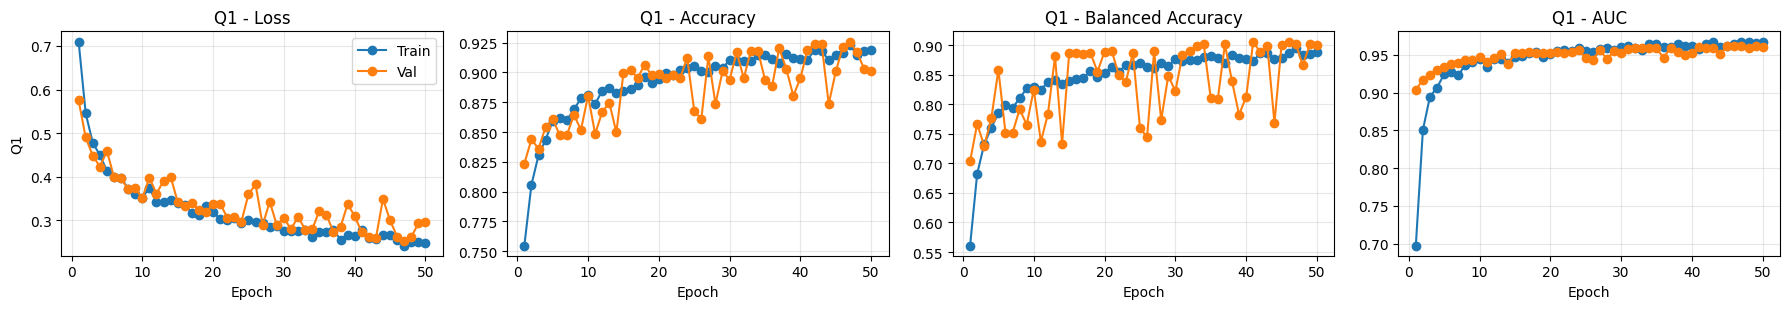

In [47]:
metrics_to_plot = [("loss", "Loss"), ("acc", "Accuracy"), ("bacc", "Balanced Accuracy"), ("auc", "AUC")]
fig, axes = plt.subplots(len(QUBITS_LIST), len(metrics_to_plot), figsize=(18, 3.2 * len(QUBITS_LIST)), squeeze=False)
for r, n_qubits in enumerate(QUBITS_LIST):
    h = all_histories[n_qubits]
    for c, (metric, title) in enumerate(metrics_to_plot):
        ax = axes[r, c]
        train_col, val_col = f"train_{metric}", f"val_{metric}"
        if train_col in h.columns: ax.plot(h["epoch"], h[train_col], marker="o", label="Train")
        if val_col in h.columns: ax.plot(h["epoch"], h[val_col], marker="o", label="Val")
        ax.set_title(f"Q{n_qubits} - {title}"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
        if c == 0: ax.set_ylabel(f"Q{n_qubits}")
        if r == 0 and c == 0: ax.legend()
plt.tight_layout(); plt.show()

## Comparación Q1 → Q5


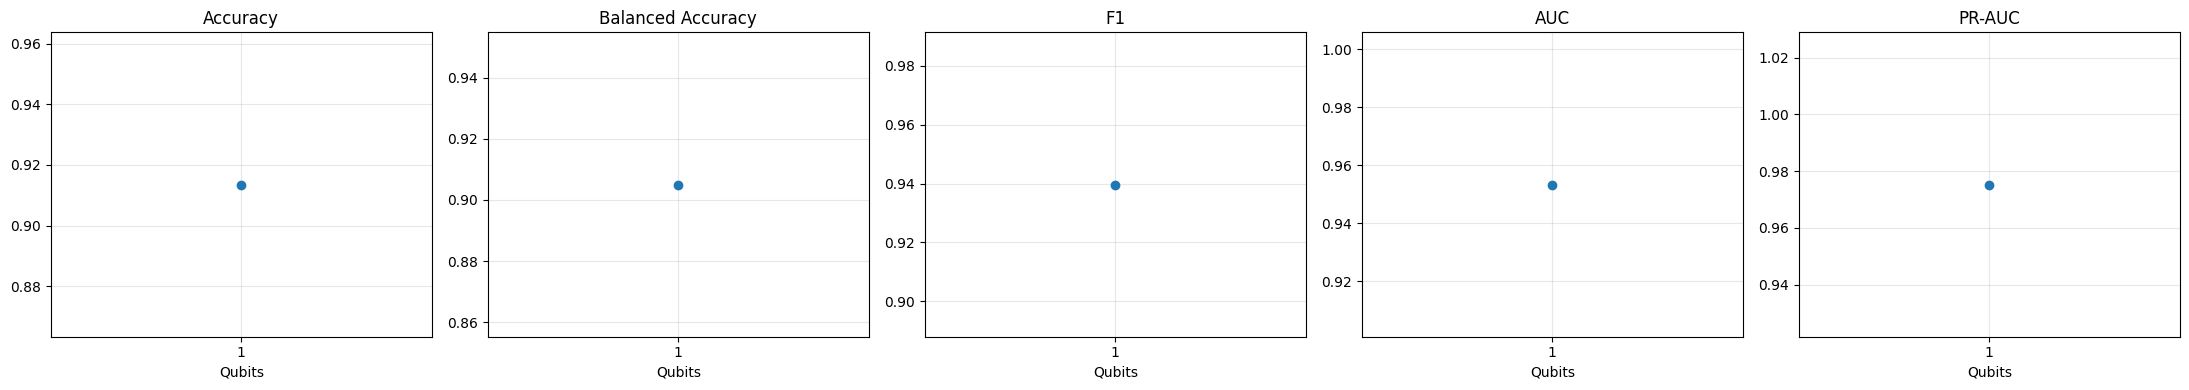

In [48]:
test_metrics_to_plot = [("Test acc", "Accuracy"), ("Test bacc", "Balanced Accuracy"), ("Test f1", "F1"), ("Test AUC", "AUC"), ("Test PR-AUC", "PR-AUC")]
fig, axes = plt.subplots(1, len(test_metrics_to_plot), figsize=(22, 4))
for ax, (col, title) in zip(axes, test_metrics_to_plot):
    ax.plot(summary_df["Qubits"], summary_df[col], marker="o")
    ax.set_title(title); ax.set_xlabel("Qubits"); ax.set_xticks(summary_df["Qubits"]); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Diagnóstico del test


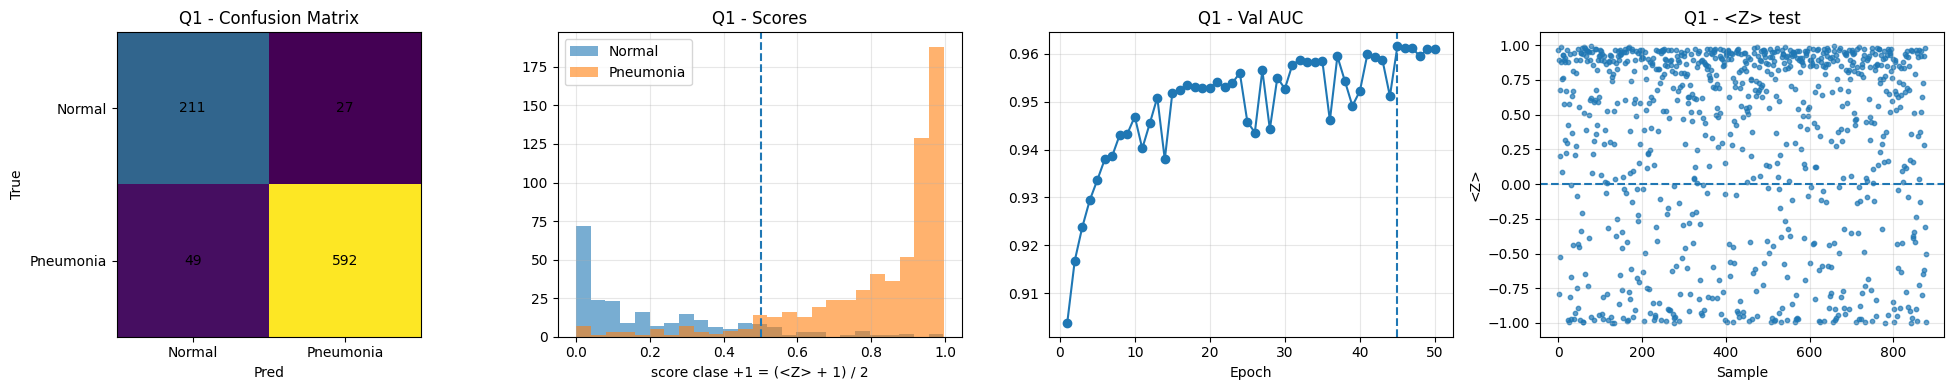

In [50]:
fig, axes = plt.subplots(len(QUBITS_LIST), 4, figsize=(20, 4 * len(QUBITS_LIST)), squeeze=False)
for r, n_qubits in enumerate(QUBITS_LIST):
    result = all_test_results[n_qubits]; y_true, exp_z = result["y"], result["exp_z"]
    y_pred = np.where(exp_z >= 0, LABEL_POS, LABEL_NEG); score_pos = (exp_z + 1.0) / 2.0
    cm = confusion_matrix(y_true, y_pred, labels=[LABEL_NEG, LABEL_POS]); h = all_histories[n_qubits]
    ax = axes[r, 0]; ax.imshow(cm); ax.set_title(f"Q{n_qubits} - Confusion Matrix")
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_xticklabels(["Normal", "Pneumonia"]); ax.set_yticklabels(["Normal", "Pneumonia"]); ax.set_xlabel("Pred"); ax.set_ylabel("True")
    for i in range(2):
        for j in range(2):
            ax.text(j, i, cm[i, j], ha="center", va="center")
    ax = axes[r, 1]; ax.hist(score_pos[y_true == LABEL_NEG], bins=25, alpha=0.6, label="Normal"); ax.hist(score_pos[y_true == LABEL_POS], bins=25, alpha=0.6, label="Pneumonia"); ax.axvline(0.5, linestyle="--")
    ax.set_title(f"Q{n_qubits} - Scores"); ax.set_xlabel("score clase +1 = (<Z> + 1) / 2"); ax.grid(True, alpha=0.3); ax.legend()
    ax = axes[r, 2]; ax.plot(h["epoch"], h["val_auc"], marker="o"); ax.axvline(result["best_epoch"], linestyle="--")
    ax.set_title(f"Q{n_qubits} - Val AUC"); ax.set_xlabel("Epoch"); ax.grid(True, alpha=0.3)
    ax = axes[r, 3]; ax.scatter(np.arange(len(exp_z)), exp_z, s=10, alpha=0.7); ax.axhline(0.0, linestyle="--")
    ax.set_title(f"Q{n_qubits} - <Z> test"); ax.set_xlabel("Sample"); ax.set_ylabel("<Z>"); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()